# 01 — Ranking & Performance Analysis

## Overview
This notebook analyses the relationship between player rankings and match performance.
Rankings are the primary metric used by the ITF and all governing bodies to assess
player quality and tournament seeding — understanding how well they predict outcomes
is fundamental to any performance analysis system.

## Questions we are answering
1. Do higher ranked players win more consistently?
2. Which ranking groups show the most volatility?
3. How often do upsets occur and at which ranking levels?
4. Is there a relationship between rank points and win rate?

## Data source
`data/processed/matches_cleaned.csv` — prepared in `00_data_cleaning.ipynb`

In [34]:
# Imports
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [35]:

# Load data
df = pd.read_csv('../data/processed/matches_cleaned.csv', parse_dates=['tourney_date'])

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nQuick check:")
print(df[['player_name', 'player_rank', 'win', 'rank_diff']].head())

Dataset loaded: 17654 rows x 21 columns

Quick check:
          player_name  player_rank  win  rank_diff
0  Abedallah Shelbayh        276.0    0      208.0
1  Abedallah Shelbayh        267.0    1      128.0
2  Abedallah Shelbayh        267.0    0      234.0
3  Abedallah Shelbayh        243.0    0      176.0
4  Abedallah Shelbayh        240.0    0      146.0


## Creating Rank Groups

In [36]:
# Explore player rank distribution
# How many unique players in each broad range?
bins = [0, 20, 50, 100, 200, 400, 2000]
labels = ['Top 20', '21-50', '51-100', '101-200', '201-400', '400+']

df['rank_group_temp'] = pd.cut(df['player_rank'], bins=bins, labels=labels)

print("Number of matches per rank group:")
print(df['rank_group_temp'].value_counts().sort_index())
print(f"\nPercentage of matches per rank group:")
print((df['rank_group_temp'].value_counts().sort_index() / len(df) * 100).round(2))

# Also check how many unique players per group
print(f"\nNumber of unique players per rank group:")
print(df.groupby('rank_group_temp', observed=True)['player_name'].nunique())

Number of matches per rank group:
rank_group_temp
Top 20     3798
21-50      4336
51-100     5388
101-200    2794
201-400     825
400+        513
Name: count, dtype: int64

Percentage of matches per rank group:
rank_group_temp
Top 20     21.51
21-50      24.56
51-100     30.52
101-200    15.83
201-400     4.67
400+        2.91
Name: count, dtype: float64

Number of unique players per rank group:
rank_group_temp
Top 20      44
21-50      104
51-100     159
101-200    272
201-400    260
400+       220
Name: player_name, dtype: int64


In [37]:
# Create final rank groups
# Drop temporary exploration column
df = df.drop(columns=['rank_group_temp'])

# Create final rank groups based on data exploration
bins = [0, 20, 100, 200, 2000]
labels = ['Elite (Top 20)', 'Tour Regular (21-100)', 'Challenger (101-200)', 'Qualifier (200+)']

df['rank_group'] = pd.cut(df['player_rank'], bins=bins, labels=labels)

print(df['rank_group'].value_counts().sort_index())

rank_group
Elite (Top 20)           3798
Tour Regular (21-100)    9724
Challenger (101-200)     2794
Qualifier (200+)         1338
Name: count, dtype: int64


## Win Percentage by Rank Groups Analysis

In [38]:
# Win % by rank group
win_by_group = df.groupby('rank_group', observed=True).agg(
    total_matches=('win', 'count'),
    wins=('win', 'sum'),
).reset_index()

win_by_group['win_pct'] = (win_by_group['wins'] / win_by_group['total_matches'] * 100).round(2)

print(win_by_group)

              rank_group  total_matches  wins  win_pct
0         Elite (Top 20)           3798  2582    67.98
1  Tour Regular (21-100)           9724  4631    47.62
2   Challenger (101-200)           2794  1171    41.91
3       Qualifier (200+)           1338   443    33.11


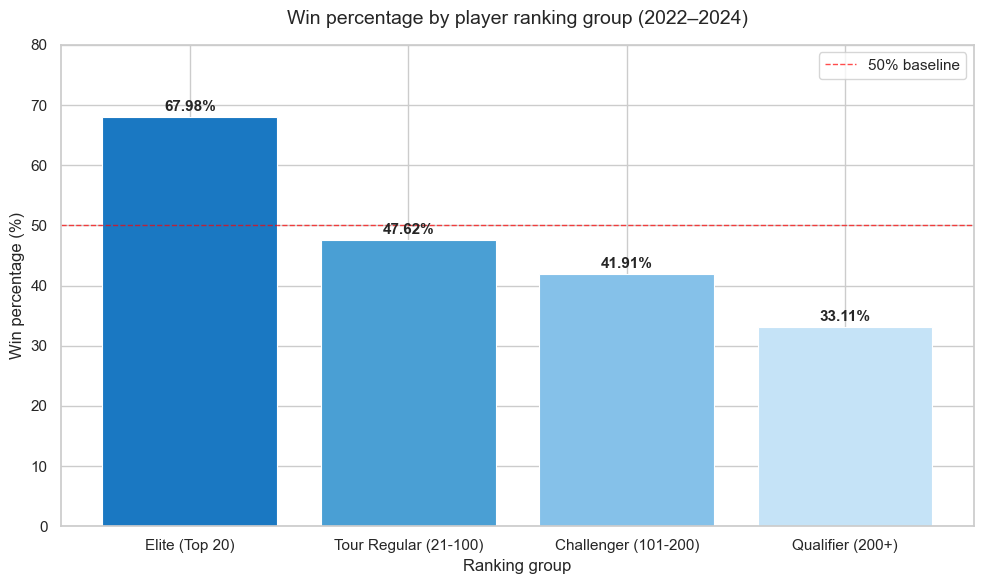

Chart saved to outputs/figures/


In [39]:
# Visualise win % by rank group
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#1a78c2', '#4a9fd4', '#85c1e9', '#c5e3f7']

bars = ax.bar(win_by_group['rank_group'], win_by_group['win_pct'], color=colors, edgecolor='white', linewidth=0.8)

# Add value labels on top of each bar
for bar, val in zip(bars, win_by_group['win_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Add a reference line at 50%
ax.axhline(y=50, color='red', linestyle='--', linewidth=1, alpha=0.7, label='50% baseline')

ax.set_title('Win percentage by player ranking group (2022–2024)', fontsize=14, pad=15)
ax.set_xlabel('Ranking group', fontsize=12)
ax.set_ylabel('Win percentage (%)', fontsize=12)
ax.set_ylim(0, 80)
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/01_win_pct_by_rank_group.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to outputs/figures/")

### Insight — Win percentage by ranking group

The data shows a clear and consistent relationship between player ranking and
match performance:

- **Elite players (Top 20)** win nearly 68% of their matches — almost 7 in every 10.
  This exceptional consistency is what separates the world's best from the rest.
- **Tour Regulars (21–100)** win just under 50%, reflecting the highly competitive
  nature of the mid-ranking tier where players are closely matched.
- **Challengers (101–200)** win 42% of matches — they can compete but struggle
  consistently against higher ranked opposition.
- **Qualifiers (200+)** win only 1 in 3 matches, confirming they are largely
  outclassed at ATP level.

The 50% baseline (red dashed line) is a useful reference — only Elite players
consistently exceed it, confirming that ranking is a strong and reliable
predictor of match outcomes at the top level.

**ITF relevance:** This analysis directly supports player ranking assessment
workflows — quantifying how well the current ranking system reflects true
competitive performance.

## Opposition Variety Analysis

In [41]:
# Consistency analysis — std of rank_diff by group
consistency = df.groupby('rank_group', observed=True).agg(
    avg_rank_diff=('rank_diff', 'mean'),
    std_rank_diff=('rank_diff', 'std'),
    avg_win_pct=('win', 'mean')
).reset_index()

consistency['avg_win_pct'] = (consistency['avg_win_pct'] * 100).round(2)
consistency['avg_rank_diff'] = consistency['avg_rank_diff'].round(2)
consistency['std_rank_diff'] = consistency['std_rank_diff'].round(2)

print(consistency)

              rank_group  avg_rank_diff  std_rank_diff  avg_win_pct
0         Elite (Top 20)         -52.64          85.56        67.98
1  Tour Regular (21-100)         -23.49         107.34        47.62
2   Challenger (101-200)          40.22         125.63        41.91
3       Qualifier (200+)         236.14         325.28        33.11


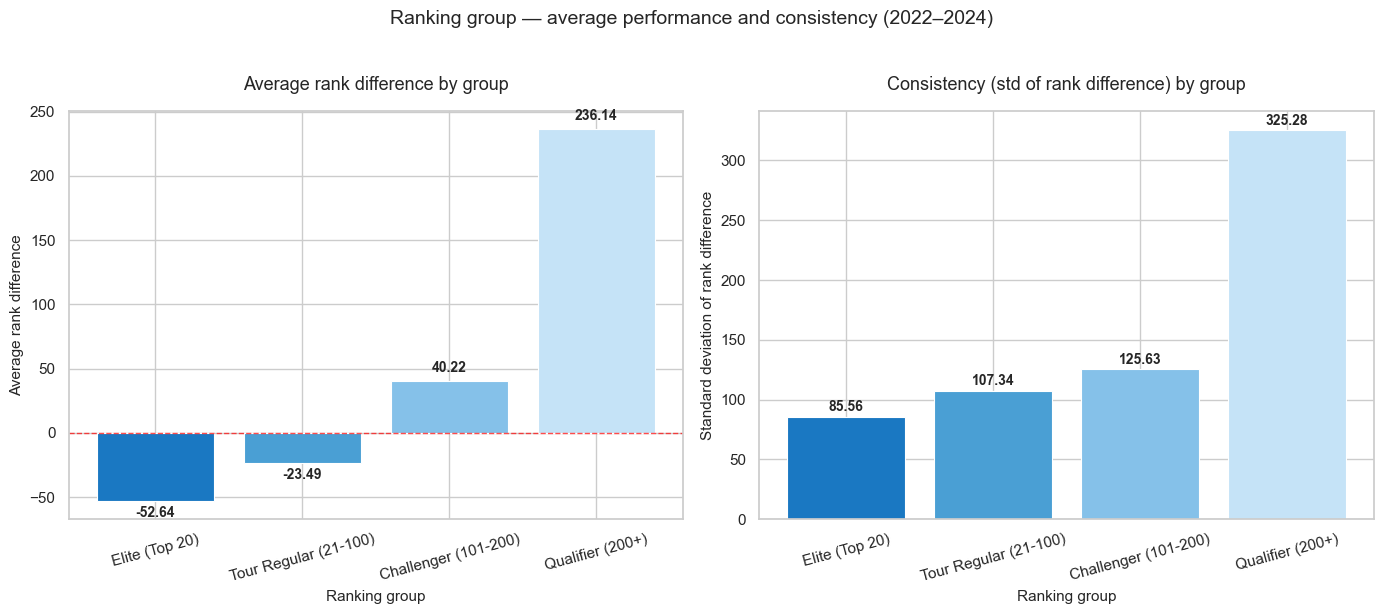

Chart saved to outputs/figures/


In [42]:
# Visualise consistency by rank group
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#1a78c2', '#4a9fd4', '#85c1e9', '#c5e3f7']

# Plot 1 — Average rank diff
bars1 = axes[0].bar(consistency['rank_group'], consistency['avg_rank_diff'],
                     color=colors, edgecolor='white', linewidth=0.8)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
for bar, val in zip(bars1, consistency['avg_rank_diff']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + (5 if val >= 0 else -15),
                 f'{val}', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[0].set_title('Average rank difference by group', fontsize=13, pad=15)
axes[0].set_xlabel('Ranking group', fontsize=11)
axes[0].set_ylabel('Average rank difference', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

# Plot 2 — Std of rank diff
bars2 = axes[1].bar(consistency['rank_group'], consistency['std_rank_diff'],
                     color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars2, consistency['std_rank_diff']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                 f'{val}', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1].set_title('Consistency (std of rank difference) by group', fontsize=13, pad=15)
axes[1].set_xlabel('Ranking group', fontsize=11)
axes[1].set_ylabel('Standard deviation of rank difference', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Ranking group — average performance and consistency (2022–2024)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/01_consistency_by_rank_group.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to outputs/figures/")

## Opposition variety analysis

### Insight — How varied are the match situations each ranking group faces?

**Standard deviation of rank difference** measures how diverse the opposition
each ranking group typically encounters:

- **Elite players (std: 85)** face the most predictable range of opponents —
  deep tournament runs mean they consistently face other highly ranked players,
  resulting in a relatively narrow band of rank differences
- **Tour Regulars (std: 107)** face moderate variety — competitive enough to
  progress in tournaments but not dominant enough to consistently face only
  top ranked opposition
- **Challengers (std: 125)** face high variety — they can draw anyone from a
  fellow challenger to a top 50 player depending on the tournament and round
- **Qualifiers (std: 325)** face by far the most unpredictable opposition —
  early rounds may pit them against fellow qualifiers while any progression
  brings them face to face with top seeds, creating extreme variability

**Key finding:** Opposition variety decreases as ranking improves. Elite players
operate in a more predictable competitive environment, which contributes to their
ability to prepare and perform consistently. Qualifiers face a lottery of
opposition that makes performance planning significantly harder.

**ITF relevance:** Understanding opposition variety helps tournament directors
assess seeding effectiveness and identify ranking groups where player development
support would have the most impact.

## Upset Analysis

In [43]:
# Upset analysis
# An upset = lower ranked player winning (rank_diff > 0 and win = 1)
upsets = df[(df['rank_diff'] > 0) & (df['win'] == 1)]
non_upsets = df[(df['rank_diff'] < 0) & (df['win'] == 1)]

print(f"Total matches: {len(df) // 2}")
print(f"Total upsets: {len(upsets)}")
print(f"Overall upset rate: {len(upsets) / (len(df) // 2) * 100:.2f}%")
print(f"\nAverage rank difference in upsets: {upsets['rank_diff'].mean():.1f}")
print(f"Largest upset (rank difference): {upsets['rank_diff'].max():.0f}")
print(f"\nBiggest upset:")
print(upsets.loc[upsets['rank_diff'].idxmax(),
    ['player_name', 'player_rank', 'opponent_rank', 'rank_diff', 'tourney_name', 'surface']])

Total matches: 8827
Total upsets: 3183
Overall upset rate: 36.06%

Average rank difference in upsets: 63.7
Largest upset (rank difference): 1295

Biggest upset:
player_name                Hong Kit Jack Wong
player_rank                            1643.0
opponent_rank                           348.0
rank_diff                              1295.0
tourney_name     Davis Cup WG2 PO: HKG vs ZIM
surface                                  Hard
Name: 8088, dtype: object


In [44]:
# Upset rate — from the favourite's perspective
# Only look at matches where there is a clear favourite (rank_diff != 0)
clear_matches = df[df['rank_diff'] != 0].copy()

# Favourite lost = higher ranked player (rank_diff < 0) but win = 0
favourite_lost = clear_matches[
    (clear_matches['rank_diff'] < 0) & (clear_matches['win'] == 0)
]

upset_rate_by_group = clear_matches[clear_matches['rank_diff'] < 0].groupby(
    'rank_group', observed=True
).apply(
    lambda g: pd.Series({
        'times_favourite': len(g),
        'times_upset': (g['win'] == 0).sum(),
        'upset_rate': (g['win'] == 0).mean() * 100
    }), include_groups=False
).reset_index()

upset_rate_by_group['upset_rate'] = upset_rate_by_group['upset_rate'].round(2)
print(upset_rate_by_group)

              rank_group  times_favourite  times_upset  upset_rate
0         Elite (Top 20)           3260.0        894.0       27.42
1  Tour Regular (21-100)           4892.0       2005.0       40.99
2   Challenger (101-200)            498.0        214.0       42.97
3       Qualifier (200+)            177.0         70.0       39.55


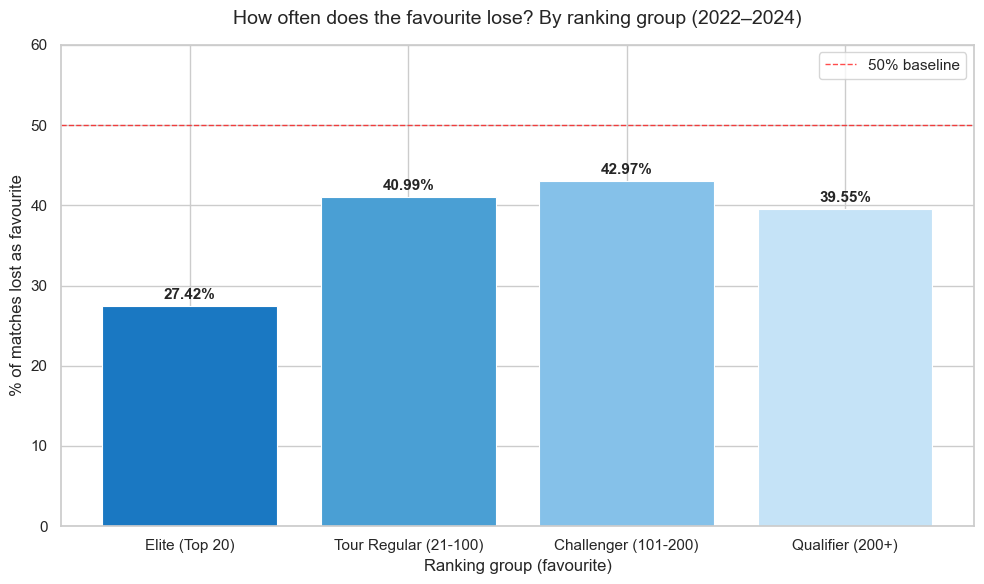

Chart saved to outputs/figures/


In [45]:
# Visualise upset rate from favourite's perspective
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#1a78c2', '#4a9fd4', '#85c1e9', '#c5e3f7']

bars = ax.bar(upset_rate_by_group['rank_group'], upset_rate_by_group['upset_rate'],
              color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, upset_rate_by_group['upset_rate']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.axhline(y=50, color='red', linestyle='--', linewidth=1, alpha=0.7, label='50% baseline')

ax.set_title('How often does the favourite lose? By ranking group (2022–2024)',
             fontsize=14, pad=15)
ax.set_xlabel('Ranking group (favourite)', fontsize=12)
ax.set_ylabel('% of matches lost as favourite', fontsize=12)
ax.set_ylim(0, 60)
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/01_upset_rate_favourite.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to outputs/figures/")

### Insight — How often does the favourite lose?

When analysing upsets, it is important to frame the question correctly.
Measuring "what % of wins are upsets" is misleading for lower ranked groups —
since Challengers and Qualifiers are almost always the underdog, virtually
any win they achieve is technically an upset by that definition.

A more meaningful question is: **when a player is the favourite, how often do
they lose?**

- **Elite players (27.4%)** are the most reliable favourites in tennis — but even
  they lose as favourite more than 1 in 4 times, highlighting that tennis is
  inherently unpredictable even at the highest level
- **Tour Regulars (41%), Challengers (43%) and Qualifiers (40%)** all lose as
  favourite at remarkably similar rates — suggesting that outside the top 20,
  the ranking system becomes a much weaker predictor of individual match outcomes

**Key takeaway:** The top 20 are genuinely in a class of their own in terms of
converting favourite status into wins. Below that threshold, any player can beat
any other on a given day.

**ITF relevance:** This finding has direct implications for tournament seeding —
only the top 20 can be reliably expected to perform to their ranking. Below that,
seeding offers limited predictive value for individual matches.

## Rank points analysis

In [46]:
# Rank points analysis
# Average rank points by group
points_by_group = df.groupby('rank_group', observed=True).agg(
    avg_points=('player_rank_points', 'mean'),
    median_points=('player_rank_points', 'median'),
    max_points=('player_rank_points', 'max')
).reset_index()

points_by_group = points_by_group.round(0)
print(points_by_group)

              rank_group  avg_points  median_points  max_points
0         Elite (Top 20)      3993.0         3355.0     11830.0
1  Tour Regular (21-100)      1008.0          920.0      2330.0
2   Challenger (101-200)       469.0          475.0       744.0
3       Qualifier (200+)       148.0          149.0       325.0


In [48]:
# Top 5 players by peak rank points
peak_points = (
    df.groupby('player_name')['player_rank_points']
    .max()
    .reset_index()
    .rename(columns={'player_rank_points': 'peak_points'})
    .nlargest(5, 'peak_points')
)

# Also get their best rank
best_rank = df.groupby('player_name')['player_rank'].min().reset_index()
best_rank.columns = ['player_name', 'best_rank']

peak_points = peak_points.merge(best_rank, on='player_name')
print("Top 5 players by peak rank points (2022-2024):")
print(peak_points.to_string(index=False))

Top 5 players by peak rank points (2022-2024):
     player_name  peak_points  best_rank
   Jannik Sinner      11830.0        1.0
  Novak Djokovic      11795.0        1.0
  Carlos Alcaraz       9815.0        1.0
 Daniil Medvedev       8935.0        1.0
Alexander Zverev       7970.0        2.0


In [49]:
# Points gap vs match outcome
# Calculate points gap between player and opponent
df['points_gap'] = df['player_rank_points'] - df['opponent_rank_points']

# Bin points gap into categories
bins = [-20000, -3000, -1000, -500, 0, 500, 1000, 3000, 20000]
labels = ['Massive deficit', 'Large deficit', 'Moderate deficit',
          'Slight deficit', 'Slight advantage',
          'Moderate advantage', 'Large advantage', 'Massive advantage']

df['points_gap_group'] = pd.cut(df['points_gap'], bins=bins, labels=labels)

# Win rate by points gap group
win_by_gap = df.groupby('points_gap_group', observed=True).agg(
    matches=('win', 'count'),
    win_rate=('win', 'mean')
).reset_index()

win_by_gap['win_rate'] = (win_by_gap['win_rate'] * 100).round(2)
print(win_by_gap)

     points_gap_group  matches  win_rate
0     Massive deficit     1148     19.77
1       Large deficit     2152     29.51
2    Moderate deficit     1774     36.58
3      Slight deficit     3755     44.58
4    Slight advantage     3757     55.47
5  Moderate advantage     1773     63.40
6     Large advantage     2148     70.48
7   Massive advantage     1147     80.21


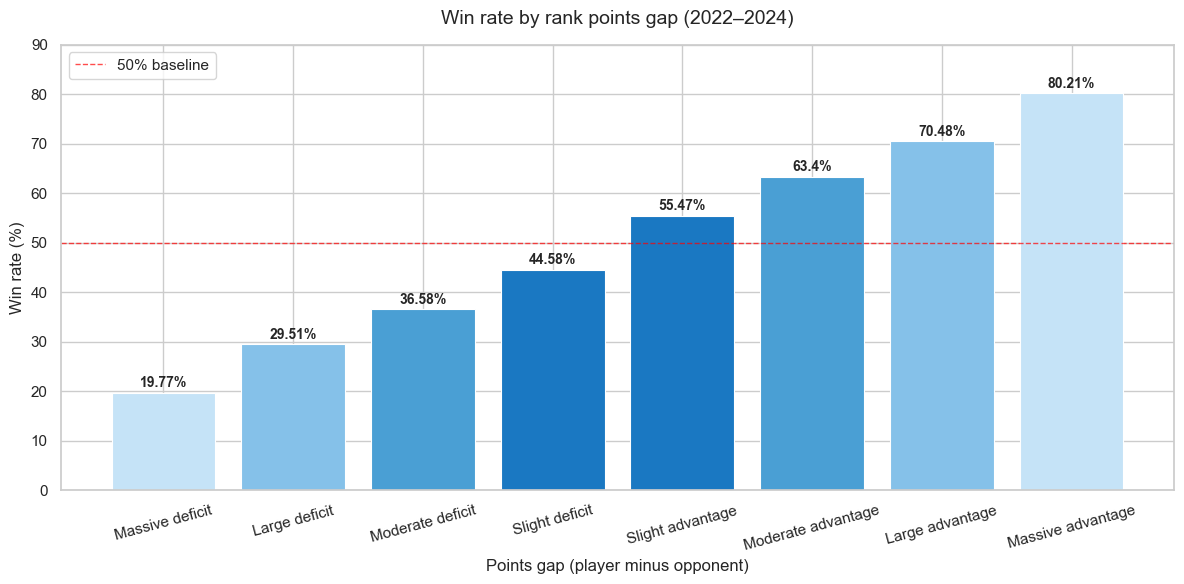

Chart saved to outputs/figures/


In [50]:
# Visualise points gap vs win rate
fig, ax = plt.subplots(figsize=(12, 6))

colors = [
    '#c5e3f7', '#85c1e9', '#4a9fd4', '#1a78c2',
    '#1a78c2', '#4a9fd4', '#85c1e9', '#c5e3f7'
]

bars = ax.bar(win_by_gap['points_gap_group'], win_by_gap['win_rate'],
              color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, win_by_gap['win_rate']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.axhline(y=50, color='red', linestyle='--', linewidth=1, alpha=0.7, label='50% baseline')

ax.set_title('Win rate by rank points gap (2022–2024)', fontsize=14, pad=15)
ax.set_xlabel('Points gap (player minus opponent)', fontsize=12)
ax.set_ylabel('Win rate (%)', fontsize=12)
ax.set_ylim(0, 90)
ax.tick_params(axis='x', rotation=15)
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/01_win_rate_by_points_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to outputs/figures/")

### Insight — Rank points gap as a predictor of match outcomes

The relationship between rank points gap and win rate is remarkably clean and
consistent — win rate increases steadily at every step from massive deficit to
massive advantage:

| Points gap | Win rate |
|---|---|
| Massive deficit | 19.77% |
| Large deficit | 29.51% |
| Moderate deficit | 36.58% |
| Slight deficit | 44.58% |
| Slight advantage | 55.47% |
| Moderate advantage | 63.40% |
| Large advantage | 70.48% |
| Massive advantage | 80.21% |

**Key finding:** Rank points gap is a stronger and more linear predictor of
match outcomes than ranking position alone. The near-perfect staircase pattern
suggests that the ATP points system does an excellent job of quantifying the
true performance gap between players.

**Notably**, even with a massive points advantage, players still lose 1 in 5
matches — further confirming the inherent unpredictability of tennis.

**ITF relevance:** Points gap could be used as a more precise metric than
ranking position alone for seeding decisions, tournament assessment, and
identifying players who are under or over ranked relative to their actual
performance level.

## Rank Group vs Tournament Level Performance Analysis

In [51]:
# Explore tournament levels
print("Tournament levels in dataset:")
print(df['tourney_level'].value_counts())

Tournament levels in dataset:
tourney_level
A    9092
M    3820
G    3038
D    1114
T     288
F     180
O     122
Name: count, dtype: int64


In [52]:
# Explore tournament names within each level
print("Sample tournaments per level:\n")
for level in df['tourney_level'].unique():
    tournaments = df[df['tourney_level'] == level]['tourney_name'].unique()
    print(f"Level '{level}' ({len(tournaments)} unique tournaments):")
    print(f"  {list(tournaments[:8])}")
    print()

Sample tournaments per level:

Level 'A' (66 unique tournaments):
  ['Doha', 'Banja Luka', 'Mallorca', 'Newport', 'Metz', 'Dubai', 'Marrakech', 'Dallas']

Level 'M' (9 unique tournaments):
  ['Madrid Masters', 'Miami Masters', 'Indian Wells Masters', 'Canada Masters', 'Paris Masters', 'Rome Masters', 'Cincinnati Masters', 'Shanghai Masters']

Level 'F' (2 unique tournaments):
  ['Next Gen Finals', 'Tour Finals']

Level 'D' (209 unique tournaments):
  ['Davis Cup WG2 R1: IND vs MAR', 'Davis Cup WG1 PO: COL vs LUX', 'Davis Cup WG1 R1: JPN vs COL', 'Davis Cup QLS R1: FRA vs ECU', 'Davis Cup Finals RR: FRA vs GER', 'Davis Cup QLS R1: FRA vs HUN', 'Davis Cup Finals RR: FRA vs SUI', 'Davis Cup Finals RR: AUS vs FRA']

Level 'G' (4 unique tournaments):
  ['Australian Open', 'Roland Garros', 'Wimbledon', 'US Open']

Level 'T' (3 unique tournaments):
  ['United Cup', 'ATP Cup', 'Laver Cup']

Level 'O' (1 unique tournaments):
  ['Paris Olympics']



In [56]:
# verify hotfix changes are reflected
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nWin distribution:\n{df['win'].value_counts()}")
print(f"\nTournament levels:\n{df['tourney_level'].value_counts()}")

# Check specific naming fixes
hertogenbosch = "'s-Hertogenbosch"
print(f"\nUS Open present: {'US Open' in df['tourney_name'].values}")
print(f"'s-Hertogenbosch present: {hertogenbosch in df['tourney_name'].values}")
print(f"Rio de Janeiro present: {'Rio de Janeiro' in df['tourney_name'].values}")
print(f"Next Gen Finals present: {'Next Gen Finals' in df['tourney_name'].values}")

# Confirm old incorrect names are gone
print(f"\nUs Open still present: {'Us Open' in df['tourney_name'].values}")
print(f"NextGen Finals still present: {'NextGen Finals' in df['tourney_name'].values}")
print(f"Atp Cup still present: {'Atp Cup' in df['tourney_name'].values}")

Total rows: 17654
Total columns: 24
Missing values: 0

Win distribution:
win
0    8827
1    8827
Name: count, dtype: int64

Tournament levels:
tourney_level
A    9092
M    3820
G    3038
D    1114
T     288
F     180
O     122
Name: count, dtype: int64

US Open present: True
's-Hertogenbosch present: True
Rio de Janeiro present: True
Next Gen Finals present: True

Us Open still present: False
NextGen Finals still present: False
Atp Cup still present: False


In [60]:
# Map tournament level codes to descriptive names
level_names = {
    'A': 'ATP 250/500',
    'M': 'Masters 1000',
    'G': 'Grand Slam',
    'D': 'Davis Cup',
    'T': 'Team Events',
    'F': 'Finals',
    'O': 'Olympics'
}

df['level_name'] = df['tourney_level'].map(level_names)

In [61]:
# Performance matrix — rank group vs tournament level
# Calculate upset rate from favourite's perspective
# for each rank group at each tournament level
matrix = df[df['rank_diff'] != 0].groupby(
    ['rank_group', 'level_name'], observed=True
).apply(
    lambda g: pd.Series({
        'total_matches': len(g),
        'win_rate': (g['win'].mean() * 100).round(2)
    }), include_groups=False
).reset_index()

# Pivot to matrix format
win_matrix = matrix.pivot(index='rank_group', columns='level_name', values='win_rate')
match_matrix = matrix.pivot(index='rank_group', columns='level_name', values='total_matches')

print("Win rate (%) by rank group and tournament level:")
print(win_matrix)
print("\nNumber of matches:")
print(match_matrix)

Win rate (%) by rank group and tournament level:
level_name             ATP 250/500  Davis Cup  Finals  Grand Slam  \
rank_group                                                          
Elite (Top 20)               68.38      62.50   49.46       74.36   
Tour Regular (21-100)        49.59      60.11   44.90       44.89   
Challenger (101-200)         42.64      52.45   57.89       33.53   
Qualifier (200+)             31.69      38.43     NaN       24.44   

level_name             Masters 1000  Olympics  Team Events  
rank_group                                                  
Elite (Top 20)                65.25     74.51        64.49  
Tour Regular (21-100)         43.39     33.33        38.54  
Challenger (101-200)          41.42     36.36        59.26  
Qualifier (200+)              36.07     16.67         7.41  

Number of matches:
level_name             ATP 250/500  Davis Cup  Finals  Grand Slam  \
rank_group                                                          
Elite (Top 2

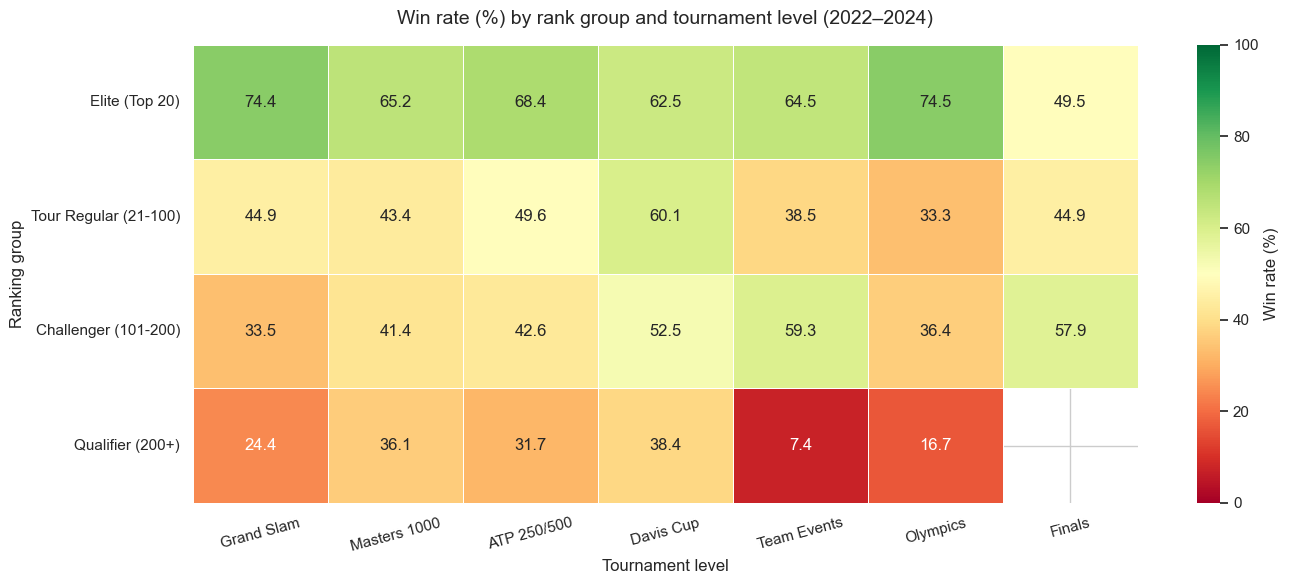

Chart saved to outputs/figures/


In [62]:
# Visualise performance matrix as heatmap
import matplotlib.pyplot as plt
import seaborn as sns

# Define column order by prestige
col_order = ['Grand Slam', 'Masters 1000', 'ATP 250/500',
             'Davis Cup', 'Team Events', 'Olympics', 'Finals']

win_matrix_ordered = win_matrix[col_order]

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    win_matrix_ordered,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=50,
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Win rate (%)'}
)

ax.set_title('Win rate (%) by rank group and tournament level (2022–2024)',
             fontsize=14, pad=15)
ax.set_xlabel('Tournament level', fontsize=12)
ax.set_ylabel('Ranking group', fontsize=12)
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/figures/01_performance_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to outputs/figures/")

### Insight — Performance matrix: rank group vs tournament level

The heatmap reveals several non-obvious patterns that go beyond simple ranking analysis:

**Elite players peak at the biggest tournaments:**
- Grand Slam win rate (74.4%) and Olympics (74.5%) are their highest across all levels
- This confirms that top 20 players not only maintain dominance but actually
  elevate their performance when the stakes are highest

**Tour Regulars and Challengers thrive in team formats:**
- Tour Regulars win 60.1% in Davis Cup — significantly higher than their
  Grand Slam rate of 44.9%
- Challengers win 52.5% in Davis Cup and 59.3% in team events
- This suggests that the team environment, home advantage, and patriotic
  motivation can meaningfully boost performance for mid-ranked players

**Qualifiers struggle most in team events (7.4%):**
- Only 27 matches — treat with caution due to small sample size
- However the pattern suggests Qualifiers face particularly strong opposition
  in team events where nations field their best available players

**Grand Slams are hardest for lower ranked players:**
- Challenger Grand Slam win rate (33.5%) is their lowest across all individual
  tournament levels
- Best of 5 sets means elite players have more time to assert dominance,
  reducing the chance of an upset compared to best of 3

**ITF relevance:** This matrix directly supports tournament assessment workflows —
understanding how different player groups perform across competition levels helps
inform seeding decisions, wildcard allocations, and player development pathways.

---

### Caveats and data limitations

Several tournament levels require careful interpretation due to their unique
formats and small sample sizes:

**Team Events (ATP Cup, United Cup, Laver Cup):**
- These are team competitions with fundamentally different dynamics to individual
  tour events — home advantage, patriotic motivation, and captains selecting
  which players compete in each rubber all influence outcomes
- Results are not directly comparable to individual tour events

**Davis Cup:**
- 209 unique ties across a wide range of competitive levels — from World Group
  qualifying ties between lower ranked nations to the Davis Cup Finals featuring
  top players
- Surface is chosen by the home nation, giving a significant home advantage
- Not directly comparable to the standardised conditions of individual tour events

**Olympics:**
- Only 122 matches from a single event (Paris 2024) — a very small sample
- Player qualification is based on nationality rather than ranking, meaning
  the field is not representative of the regular tour
- Held only every 4 years, making multi-year trend analysis impossible

**Finals (Tour Finals + Next Gen Finals):**
- Tour Finals features only the top 8 players — results are not comparable
  to regular tournaments with full draws
- Next Gen Finals features only under-21 players — a completely different
  competitive pool
- Round robin format differs from the knockout draws used in all other events
- Combined they account for only 180 matches — a small sample

**General note:** Where sample sizes are small (particularly Olympics and Team
Events for lower ranked groups), findings should be treated as indicative rather
than statistically conclusive.

## Summary & Conclusions

This notebook analysed the relationship between player rankings and match
performance across ATP tour events from 2022–2024.

### Key findings

| Finding | Detail |
|---|---|
| Ranking predicts outcomes | Elite players win 68% of matches — ranking is a strong but imperfect predictor |
| Elite players are uniquely reliable | Only the top 20 consistently convert favourite status into wins (73% of the time) |
| Points gap is more precise than rank | A linear relationship exists between points gap and win rate — from 20% to 80% |
| Elite players elevate at big tournaments | Grand Slam win rate (74.4%) is their highest across all tournament levels |
| Team formats boost mid-ranked players | Tour Regulars win 60.1% in Davis Cup vs 44.9% at Grand Slams |
| Tennis is inherently unpredictable | Even with a massive points advantage, players still lose 1 in 5 matches |

### Limitations
- Davis Cup, Olympics, Team Events and Finals have unique formats that make
  direct comparison with individual tour events difficult
- Small sample sizes for Olympics (122 matches) and Finals (180 matches)
  mean findings for those levels should be treated as indicative only
- Analysis covers 2022–2024 only — longer term trends may differ

### ITF relevance
This analysis directly supports player ranking assessment workflows and tournament
evaluation. The performance matrix in particular offers a novel view of how
different player groups perform across competition levels — useful for seeding
decisions, wildcard allocations, and junior pathway planning.